In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
os.listdir('/content/drive/MyDrive/Colab')

['placement_dataset.csv',
 'placement_predict_50k Dataset (1) (1).csv',
 'placement_predict_50k_adjusted.csv',
 'age_insurance.csv',
 'simple_placement_dataset.csv',
 'movies_dataset(1).csv',
 'WineQT.csv',
 'WineQT_Feature_Engineered.csv',
 'placement_predict_50k_adjusted (1).csv',
 'student_data.csv',
 'xgboost_lightgbm_shap_student_dataset.csv',
 'iris_dataset.csv',
 'breast_cancer_classification_dataset (1).csv',
 'mall_customers_clustering_dataset.csv',
 'digits_pca_tsne_umap_dataset.csv',
 'isolation_forest_dataset.csv',
 'socioeconomic_profiling_dataset.csv',
 'ml_cross_validation_calibration_dataset.csv',
 'hyperparameter_tuning_dataset.csv',
 'evaluation_threshold_calibration_dataset.csv',
 'student_performance.csv',
 'student_performance_mlops.csv',
 'dimensionality_reduction_anomaly_detection_dataset.csv',
 'data_leakage_cross_validation_nested_cv_dataset.csv',
 'full_metrics_classification_dataset.csv']

In [3]:
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Colab/placement_dataset.csv')

First 5 rows:
  Customer_ID    Age  Annual_Income  Credit_Score  Debt_Ratio  \
0       C0001  47.96       71889.11        667.20       0.171   
1       C0002  40.34       45711.19        776.24       0.228   
2       C0003  49.77       56730.17        634.78       0.082   
3       C0004  60.28       46679.04        624.06       0.552   
4       C0005  39.19       47179.07        646.21       0.195   

   Employment_Years  Previous_Defaults  Loan_Amount   Savings  Default  
0              8.21                  1     34104.18  19377.31        0  
1              2.86                  0     27902.61  13383.59        0  
2              2.16                  0      5000.00  22397.52        0  
3              3.69                  1     15482.56   2388.24        1  
4             10.22                  0     43114.97   7897.07        0  

Dataset shape: (800, 10)

Class distribution:
Default
0    729
1     71
Name: count, dtype: int64

Confusion Matrix:
[[146   0]
 [ 14   0]]

Classification 

/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


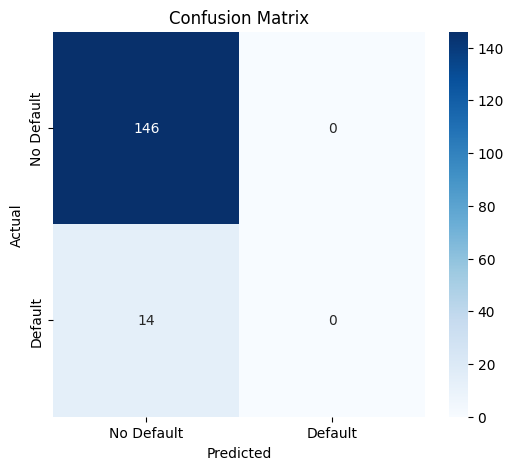


ROC-AUC: 0.6795499021526419


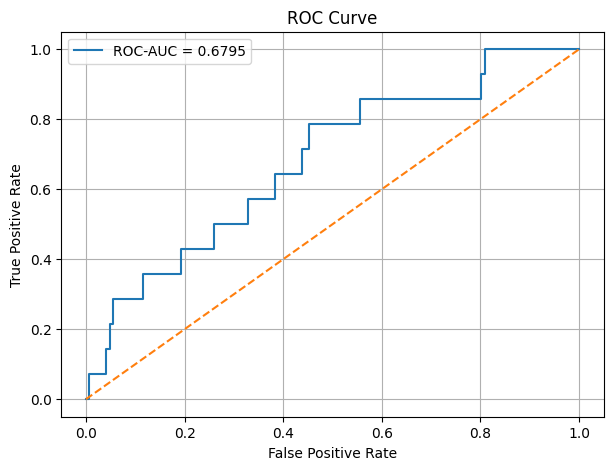


PR-AUC: 0.170434360867688
Average Precision: 0.20264543055949943


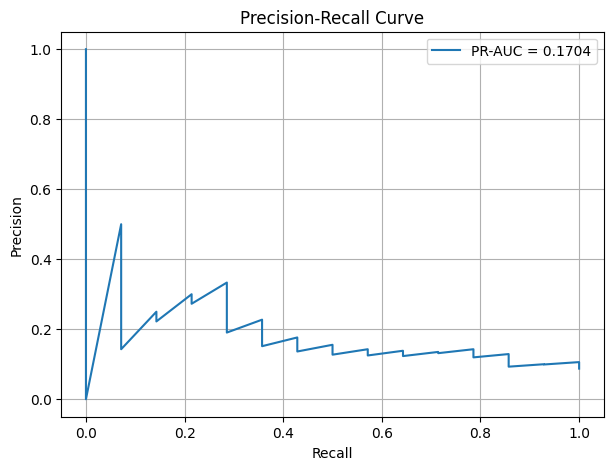


Brier Score: 0.07649200795979214


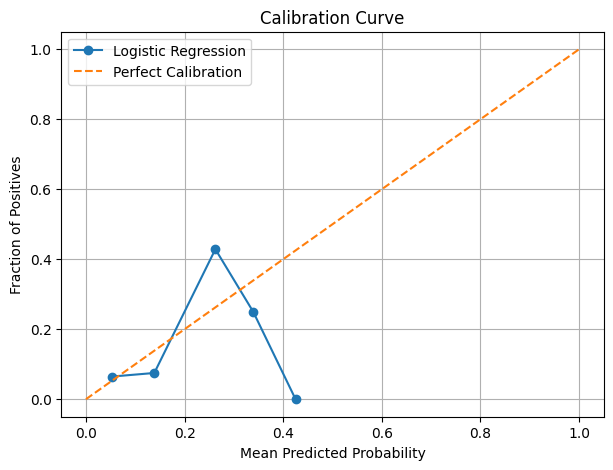


McNemar Contingency Table:
col_0  False  True 
row_0              
False     13      1
True       2    144

McNemar Test Statistic: 0.0
McNemar Test p-value: 1.0
Result: No statistically significant difference was detected
between the paired prediction errors.

========== FULL METRICS SUITE ==========
           Metric    Value
         Accuracy 0.912500
        Precision 0.000000
           Recall 0.000000
      Specificity 1.000000
         F1 Score 0.000000
          ROC-AUC 0.679550
           PR-AUC 0.170434
      Brier Score 0.076492
McNemar Statistic 0.000000
  McNemar p-value 1.000000

Completed successfully.
Saved:
- full_metrics_predictions.csv
- full_metrics_summary.csv


In [6]:
 # Full Metrics Suite:
# Confusion Matrix, ROC-AUC, PR-AUC, Calibration, McNemar Test
# Machine Learning Classification Project

# Install if required:
# pip install pandas numpy matplotlib seaborn scikit-learn statsmodels

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    auc,
    average_precision_score,
    brier_score_loss
)
from sklearn.calibration import calibration_curve
from statsmodels.stats.contingency_tables import mcnemar

# =========================================================
# 1. Load Dataset
# =========================================================
df = pd.read_csv("/content/drive/MyDrive/Colab/full_metrics_classification_dataset.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset shape:", df.shape)
print("\nClass distribution:")
print(df["Default"].value_counts())

# Customer_ID is an identifier, not a feature
X = df.drop(columns=["Customer_ID", "Default"])
y = df["Default"]

# =========================================================
# 2. Train-Test Split
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# =========================================================
# 3. Train Logistic Regression Model
# =========================================================
model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=2000))
])

model.fit(X_train, y_train)

# Predicted class and probability
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# =========================================================
# 4. CONFUSION MATRIX
# =========================================================
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Default", "Default"],
    yticklabels=["No Default", "Default"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# =========================================================
# 5. ROC-AUC
# =========================================================
roc_auc = roc_auc_score(y_test, y_prob)

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

print("\nROC-AUC:", roc_auc)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

# =========================================================
# 6. PR-AUC
# =========================================================
precision, recall, pr_thresholds = precision_recall_curve(
    y_test,
    y_prob
)

pr_auc = auc(recall, precision)
average_precision = average_precision_score(y_test, y_prob)

print("\nPR-AUC:", pr_auc)
print("Average Precision:", average_precision)

plt.figure(figsize=(7, 5))
plt.plot(
    recall,
    precision,
    label=f"PR-AUC = {pr_auc:.4f}"
)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.show()

# =========================================================
# 7. CALIBRATION
# =========================================================
# Calibration checks whether predicted probabilities
# correspond to observed frequencies.

fraction_of_positives, mean_predicted_value = calibration_curve(
    y_test,
    y_prob,
    n_bins=10,
    strategy="uniform"
)

brier = brier_score_loss(y_test, y_prob)

print("\nBrier Score:", brier)

plt.figure(figsize=(7, 5))
plt.plot(
    mean_predicted_value,
    fraction_of_positives,
    marker="o",
    label="Logistic Regression"
)
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)
plt.xlabel("Mean Predicted Probability")
plt.ylabel("Fraction of Positives")
plt.title("Calibration Curve")
plt.legend()
plt.grid(True)
plt.show()

# =========================================================
# 8. McNEMAR'S TEST
# =========================================================
# McNemar's test compares the errors of TWO classifiers
# on the SAME test observations.
#
# We create a second classifier using a different
# decision threshold for demonstration.

y_pred_model_1 = (y_prob >= 0.50).astype(int)
y_pred_model_2 = (y_prob >= 0.35).astype(int)

# Build paired 2x2 table:
# rows = Model 1 correctness
# cols = Model 2 correctness

model1_correct = (y_pred_model_1 == y_test.values)
model2_correct = (y_pred_model_2 == y_test.values)

table = pd.crosstab(
    model1_correct,
    model2_correct
).reindex(
    index=[False, True],
    columns=[False, True],
    fill_value=0
)

print("\nMcNemar Contingency Table:")
print(table)

result = mcnemar(
    table,
    exact=False,
    correction=True
)

print("\nMcNemar Test Statistic:", result.statistic)
print("McNemar Test p-value:", result.pvalue)

if result.pvalue < 0.05:
    print("Result: The two classifiers have a statistically significant")
    print("difference in their paired prediction errors.")
else:
    print("Result: No statistically significant difference was detected")
    print("between the paired prediction errors.")

# =========================================================
# 9. Final Metrics Summary
# =========================================================
tn, fp, fn, tp = cm.ravel()

accuracy = (tp + tn) / (tp + tn + fp + fn)
precision_value = tp / (tp + fp) if (tp + fp) else 0
recall_value = tp / (tp + fn) if (tp + fn) else 0
specificity = tn / (tn + fp) if (tn + fp) else 0
f1 = (
    2 * precision_value * recall_value /
    (precision_value + recall_value)
    if (precision_value + recall_value) else 0
)

summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "Specificity",
        "F1 Score",
        "ROC-AUC",
        "PR-AUC",
        "Brier Score",
        "McNemar Statistic",
        "McNemar p-value"
    ],
    "Value": [
        accuracy,
        precision_value,
        recall_value,
        specificity,
        f1,
        roc_auc,
        pr_auc,
        brier,
        result.statistic,
        result.pvalue
    ]
})

print("\n========== FULL METRICS SUITE ==========")
print(summary.to_string(index=False))

# =========================================================
# 10. Save Results
# =========================================================
results = X_test.copy()
results["Actual_Default"] = y_test.values
results["Predicted_Default"] = y_pred
results["Predicted_Probability"] = y_prob

results.to_csv(
    "full_metrics_predictions.csv",
    index=False
)

summary.to_csv(
    "full_metrics_summary.csv",
    index=False
)

print("\nCompleted successfully.")
print("Saved:")
print("- full_metrics_predictions.csv")
print("- full_metrics_summary.csv")
